# Setup

This imports the packages we will use for visualization as well as load in some functions that will help visualize your output. You can skip over these and go straight to Problem 1

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
def draw_snowman(snowman_x, snowman_y, snowman_size, title="My Snowman", figsize=(6, 8)):
    """Draw a snowman with any number of circles, with arms on the second circle if present."""

    # Make sure all three lists are the same length
    assert len(snowman_x) == len(snowman_y), (
        f"Every circle needs both an X and a Y coordinate — looks like you have "
        f"{len(snowman_x)} X value(s) but {len(snowman_y)} Y value(s) in snowman_y. "
        f"Looks like part of your snowman is floating in a mysterious void! Make sure you have the same number of X and Y values"
    )
    assert not (len(snowman_x) > len(snowman_size)), (
        f"Every circle needs a size — looks like you have "
        f"{len(snowman_x)} circle(s) but {len(snowman_size)} size(s) in snowman_size "
        f"Every snowball needs a size even if it is small"
    )
    assert not (len(snowman_x) < len(snowman_size)), (
        f"Every circle needs both an X and a Y coordinate "
        f"{len(snowman_x)} circle(s) but {len(snowman_size)} size(s) in snowman_size. "
        f"Looks like part of your snowman is floating in a mysterious void! Give it coordinates"
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Draw however many circles were passed in
    for i in range(len(snowman_x)):
        circle = plt.Circle(
            (snowman_x[i], snowman_y[i]),
            snowman_size[i],
            color='white', ec='black', lw=2, zorder=2
        )
        ax.add_patch(circle)

    # Draw arms on the second circle (index 1) only if it exists
    if len(snowman_x) > 1:
        arm_scale = snowman_size[1] / 0.7
        ax.plot(
            [snowman_x[1] - snowman_size[1],  snowman_x[1] - snowman_size[1] - 0.9 * arm_scale],
            [snowman_y[1] + 0.15 * arm_scale, snowman_y[1] + 0.6 * arm_scale],
            color='saddlebrown', lw=3, solid_capstyle='round', zorder=1
        )
        ax.plot(
            [snowman_x[1] + snowman_size[1],  snowman_x[1] + snowman_size[1] + 0.9 * arm_scale],
            [snowman_y[1] + 0.15 * arm_scale, snowman_y[1] + 0.6 * arm_scale],
            color='saddlebrown', lw=3, solid_capstyle='round', zorder=1
        )

    ax.set_xlim(-4, 4)
    ax.set_ylim(-1.5, 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#daeef7')
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-1, 6))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_title(title, fontsize=14, pad=12)

    plt.tight_layout()
    plt.show()
    
    
    
# ── draw_snowman() ────────────────────────────────────────────────────────────
def draw_snowman_from_dict(snowman, title="My Snowman", figsize=(6, 8)):
    """Draw a snowman from a list of snowball dictionaries."""

    assert len(snowman) > 0, (
        "Your snowman has no circles! Add at least one dictionary to the snowman list."
    )

    fig, ax = plt.subplots(figsize=figsize)

    for ball in snowman:

        # Make sure each dictionary has all the required keys
        for key in ["X", "Y", "size", "has_arms", "color"]:
            assert key in ball, (
                f"One of your snowballs is missing the '{key}' key — "
                f"every snowball needs X, Y, size, has_arms, and color!"
            )

        # Draw the circle
        circle = plt.Circle(
            (ball["X"], ball["Y"]),
            ball["size"],
            color=ball["color"], ec='black', lw=2, zorder=2
        )
        ax.add_patch(circle)

        # Draw arms if this snowball has them
        if ball["has_arms"]:
            arm_scale = ball["size"] / 0.7
            ax.plot(
                [ball["X"] - ball["size"],  ball["X"] - ball["size"] - 0.9 * arm_scale],
                [ball["Y"] + 0.15 * arm_scale, ball["Y"] + 0.6 * arm_scale],
                color='saddlebrown', lw=3, solid_capstyle='round', zorder=1
            )
            ax.plot(
                [ball["X"] + ball["size"],  ball["X"] + ball["size"] + 0.9 * arm_scale],
                [ball["Y"] + 0.15 * arm_scale, ball["Y"] + 0.6 * arm_scale],
                color='saddlebrown', lw=3, solid_capstyle='round', zorder=1
            )

    ax.set_xlim(-4, 4)
    ax.set_ylim(-1.5, 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#daeef7')
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-1, 6))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_title(title, fontsize=14, pad=12)

    plt.tight_layout()
    plt.show()
    
# ── draw_sequence() ───────────────────────────────────────────────────────────
def draw_sequence(color_list, sequence, title="My Sequence", figsize=(12, 2)):
    """Draw a row of colored squares with the base letter centered in each square."""

    assert len(color_list) > 0, (
        "Your color list is empty! Make sure you mapped your sequence correctly."
    )
    assert len(color_list) == len(sequence), (
        f"Your color list has {len(color_list)} entries but your sequence has "
        f"{len(sequence)} bases — they need to be the same length!"
    )

    fig, ax = plt.subplots(figsize=figsize)

    for i, (color, base) in enumerate(zip(color_list, sequence)):
        square = patches.Rectangle(
            (i, 0),
            1, 1,
            color=color, ec='white', lw=2, zorder=2
        )
        ax.add_patch(square)

        # Print the base letter centered in the square
        ax.text(
            i + 0.5, 0.5,        # center of the square
            base,
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', zorder=3
        )

    ax.set_xlim(0, len(color_list))
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, pad=12)

    plt.tight_layout()
    plt.show()

# Problem 1:
Uh oh — it's been a warm winter in Seattle! It's April and it's barely snowed once. You finally built a snowman using shaved ice from your freezer, but even that wasn't enough — after ten minutes outside he's already falling apart. His middle has slid off to one side, and his head has rolled off entirely.

## Setup:

The draw_snowman function takes two lists (one for the X-coordinates, one for the Y-coordinates) and one variable for the size of the snowman. I've already set up the default snowman.

## Your job:

Adjust the variables describing the snowman to show what happened to him. Try to change the values so that:
- He has shrunk
- His middle has slid off to one side
- His head has rolled away

*Bonus: Try adding new entries to the list to see what happened*


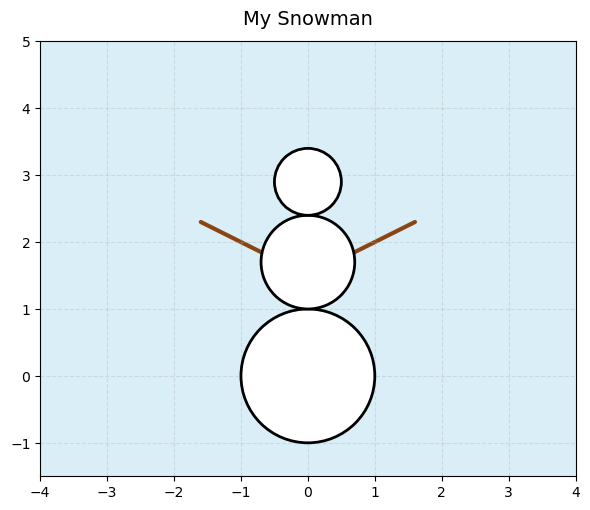

In [3]:
# ── Snowman variables ─────────────────────────────────────────────────────────

# Scaling factor for snowman size
scale = 1.0

# Left/right position of each circle.
snowman_x = [0, 0, 0]

# Up/down position of each circle. (Calculated so circles stack perfectly on top of each other)
snowman_y = [0,
             (1.0 + 0.7) * scale,
             (1.0 + 0.7 + 0.7 + 0.5) * scale]


# Radius of each circle — larger number means bigger circle
snowman_size = [1.0 * scale,
                0.7 * scale,
                0.5 * scale]

# ── Draw ──────────────────────────────────────────────────────────────────────
draw_snowman(snowman_x, snowman_y, snowman_size)

# Problem 2:
These two snowmen have been staring each other down across the yard all morning. The one on the left has had enough — he's ready to throw some snowballs. 

## Setup

The draw_snowman_from_dict function takes 1 argument, a list of snowball dictonaries. It will plot each snowball in the list. I have already set up the two snowmen.

Each snowball dictionary has the following feilds:
- X - the X position of the snowball
- Y - the Y position of the snowball
- size - size of the snowball
- has_arms - if the snowball has arms
- color - the color of the snowball

## Your job:

- Add one or more snowballs to the scene by adding new dictionaries to the scene list (using append)
- Add multiple snowballs at different positions to make it look like a whole volley is in the air.
- Bonus challenge 2: the snowman on the right just got hit — move his sections around to show him falling over (like you did in the last exercise!).
- Bonus challenge 3: To be extra mean one of the snowmen is throwing a sentient snowball, with arms

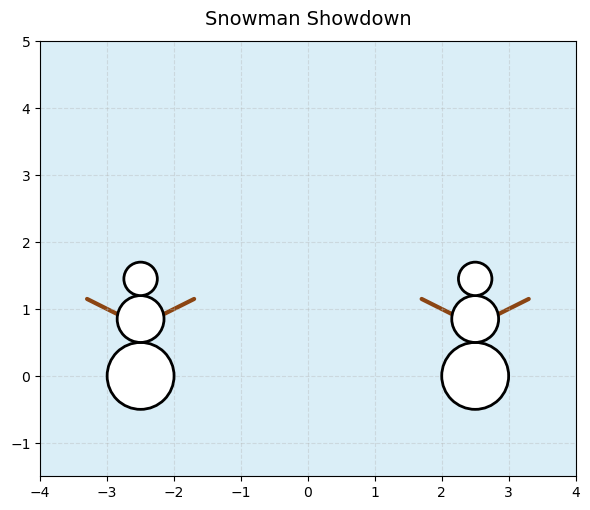

In [4]:
# ── Snowman variables ─────────────────────────────────────────────────────────
# Each section of the snowman is a dictionary with its own properties.
# has_arms controls whether stick arms are drawn on that section.

left_bottom = {"X": -2.5, "Y": 0,    "size": 0.5,  "has_arms": False, "color": "white"}
left_middle = {"X": -2.5, "Y": 0.85, "size": 0.35, "has_arms": True,  "color": "white"}
left_top    = {"X": -2.5, "Y": 1.45, "size": 0.25, "has_arms": False, "color": "white"}


right_bottom = {"X": 2.5, "Y": 0,    "size": 0.5,  "has_arms": False, "color": "white"}
right_middle = {"X": 2.5, "Y": 0.85, "size": 0.35, "has_arms": True,  "color": "white"}
right_top    = {"X": 2.5, "Y": 1.45, "size": 0.25, "has_arms": False, "color": "white"}





# add your dictionaries to this list to plot the snowballs
snowman = [left_bottom, left_middle, left_top, 
           right_bottom, right_middle, right_top]





# ── Draw ──────────────────────────────────────────────────────────────────────
draw_snowman_from_dict(snowman, title="Snowman Showdown")

# Problem 3:

Now for something a bit more biology-relevant. Dictionaries are great for mapping one set of values to another — for example, nucleotide bases to colors, scores, or even other bases. Below we set up some code that visualizes each base as a colored square. Using similar logic, your job is to find the complementary bases for a given DNA sequence.

## Setup
You are given:
- sequence — a string of nucleotide bases representing the top strand of a DNA molecule
- draw_sequence(color_list, sequence) — a function that plots each base as a colored square

An example of how to use a dictionary to map bases to colors, and build up a result with a for loop, is provided as a reference.


## Your job:

- Write a dictonary that "translates" from one base to it's complement (A <-> T, C <-> G)
- Use a for loop to go through each base in sequence and look up its complement in your dictionary, building up a new string called complementary_strand — you can use the example code as a scaffold

### Example/setup

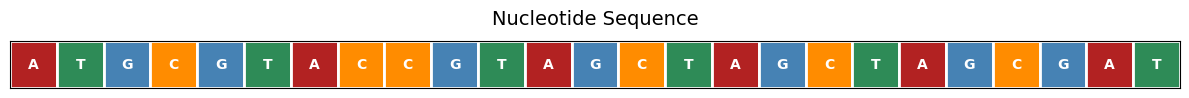

In [16]:
sequence = "ATGCGTACCGTAGCTAGCTAGCGAT"

# These are our colors for each diffrent type of base
nucleotide_colors = {
    "A": "firebrick",
    "G": "steelblue",
    "C": "darkorange",
    "T": "seagreen",
}



# Now we do the mapping 

## first we setup an empty list
color_sequence = []

# this goes through each letter of the string
for base in sequence:
    # here we add the color to our list color_sequence
    color_sequence.append(nucleotide_colors[base])



# look at the result
draw_sequence(color_sequence, sequence, title="Nucleotide Sequence")

### Exercise

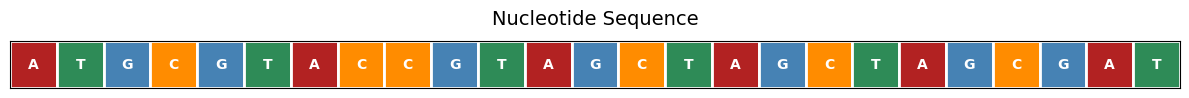

In [16]:
base_mapper = {}


# translate to the other strand
bottom_sequence = 

for base in sequence:
    

# this gets you the color sequence for the bottom strand
color_sequence_bottom = [nucleotide_colors[b] for b in bottom_sequence]


# look at the result
draw_sequence(color_sequence, sequence, title="Nucleotide Sequence (top strand)")
draw_sequence(color_sequence_bottom, bottom_sequence, title="Nucleotide Sequence (bottom strand)")